### The longest match recorded in terms of duration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os

In [3]:
period_parquet_path = "D:/Daneshkar/Project-1(Tennis)/data/input/tennis_data/**/data/raw/raw_match_parquet/*.parquet"
all_perquet_files = glob(period_parquet_path, recursive=True)
limit_files = sorted(set(os.path.dirname(f) for f in all_perquet_files))
selected_folder = limit_files[:]
selected_files = [f for f in all_perquet_files if os.path.dirname(f) in selected_folder]
combined_df = pd.concat([pd.read_parquet(f) for f in selected_files], ignore_index=True)
display(combined_df)
display(combined_df.info())

C:\Users\moham\AppData\Local\Temp\ipykernel_20832\532588588.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([pd.read_parquet(f) for f in selected_files], ignore_index=True)


,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,...,tennis_points,has_event_player_statistics,crowd_sourcing_enabled,has_performance_graph_feature,display_inverse_home_away_teams,priority,competition_type,city,stadium,venue_id
0,11998445,Auger-Aliassime F.,auger-aliassime-felix,M,23318.0,"Monte Carlo, Monaco","Montreal, Canada",1.93,87.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11998446,Cobolli F.,flavio-cobolli,M,5995.0,Rome,"Florence, Italy",1.83,71.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11998447,Martínez P.,martinez-pedro,M,2621.0,"Valencia, Spain","Alzira, Spain",1.85,76.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11998448,Muller A.,muller-alexandre,M,2443.0,France,"Poissy, France",1.83,73.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11998449,Mayot H.,mayot-harold,M,1492.0,"Marly, France","Metz, France",1.78,78.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316797,12213482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 5,18337.0
316798,12213483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 8,18581.0
316799,12213484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 6,18336.0
316800,12213486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 7,18289.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316802 entries, 0 to 316801
Data columns (total 62 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   match_id                         316802 non-null  int64  
 1   name                             104767 non-null  object 
 2   slug                             69096 non-null   object 
 3   gender                           49745 non-null   object 
 4   user_count                       85484 non-null   float64
 5   residence                        14205 non-null   object 
 6   birthplace                       28669 non-null   object 
 7   height                           27861 non-null   float64
 8   weight                           13942 non-null   float64
 9   plays                            24443 non-null   object 
 10  turned_pro                       9531 non-null    object 
 11  current_prize                    49457 non-null   float64
 12  to

None

In [4]:
# Sum duration of all periods
combined_df['total_duration'] = (
    combined_df[['period_1', 'period_2', 'period_3', 'period_4', 'period_5']]
    .fillna(0)  # In case some matches had fewer sets
    .sum(axis=1)
)

# the match with the longest duration
longest_match = combined_df.loc[combined_df['total_duration'].idxmax()]

# Print the result
print("Longest Match Details:")
print(longest_match[['match_id', 'total_duration']])


Longest Match Details:
match_id          12063611
total_duration    336790.0
Name: 51801, dtype: object


C:\Users\moham\AppData\Local\Temp\ipykernel_20832\4279563391.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)  # In case some matches had fewer sets


C:\Users\moham\AppData\Local\Temp\ipykernel_20832\2832569264.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moham\AppData\Local\Temp\ipykernel_20832\2832569264.py:5: UserWarning: The palette list has more values (35) than needed (10), which may not be intended.
  sns.barplot(


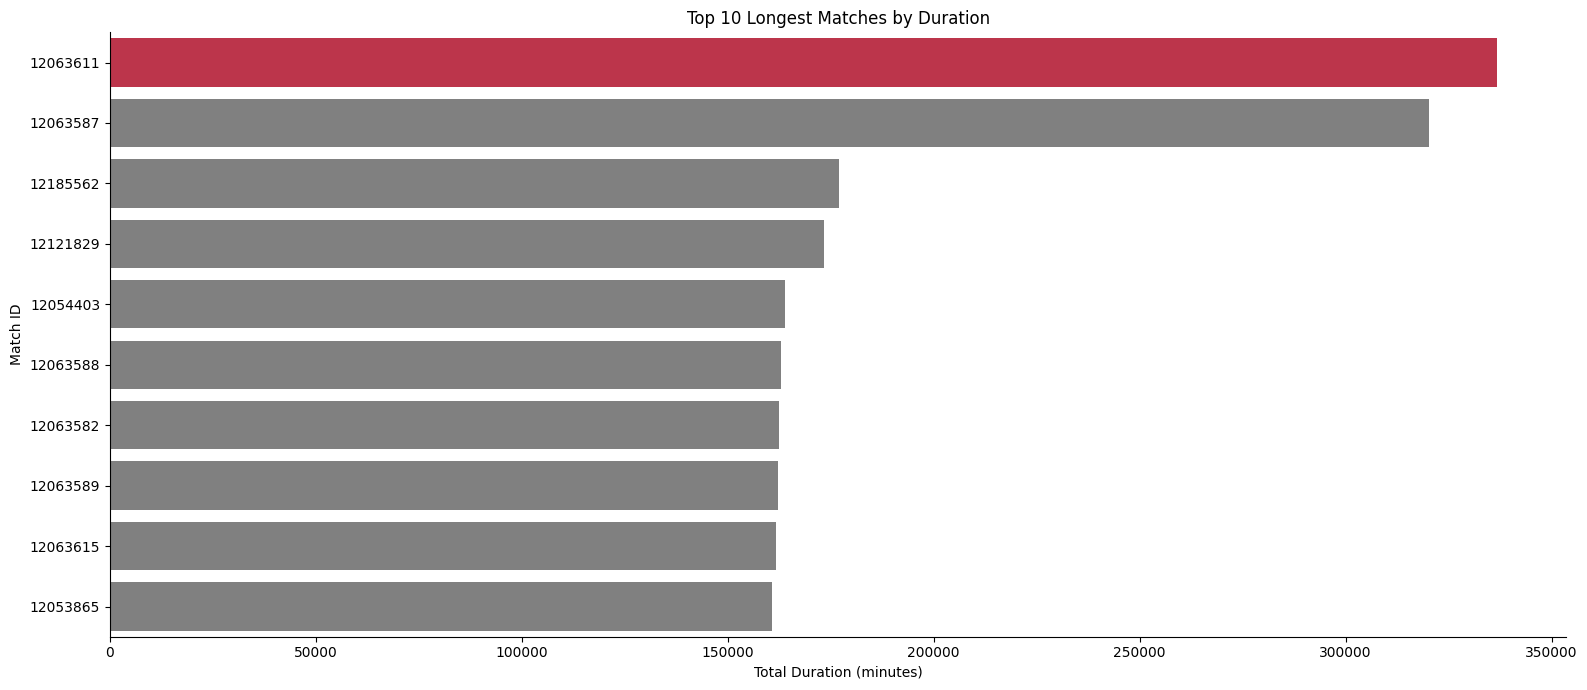

In [ ]:
import seaborn as sns
top_matches = combined_df.sort_values(by='total_duration', ascending=False).head(10)

plt.figure(figsize=(16, 7))
sns.barplot(
    x='total_duration',
    y=top_matches['match_id'].astype(str),
    data=top_matches,
    palette=['#d21f3c'] + ['gray']*(len(top_matches)-1)
)

# Titles and labels
plt.title('Top 10 Longest Matches by Duration')
plt.xlabel('Total Duration (minutes)')
plt.ylabel('Match ID')

# Remove top and right borders
sns.despine(top=True, right=True)

# Show plot
plt.tight_layout()
plt.show()
